<a href="https://colab.research.google.com/github/DarshaPadmanban/24ADI003_24BAD017/blob/main/24BAD017_ML_EXP_9(SC_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget http://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip ml-100k.zip

--2026-04-08 14:09:43--  http://files.grouplens.org/datasets/movielens/ml-100k.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://files.grouplens.org/datasets/movielens/ml-100k.zip [following]
--2026-04-08 14:09:44--  https://files.grouplens.org/datasets/movielens/ml-100k.zip
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4924029 (4.7M) [application/zip]
Saving to: ‘ml-100k.zip’

ml-100k.zip         100%[===================>]   4.70M  20.2MB/s    in 0.2s    

2026-04-08 14:09:44 (20.2 MB/s) - ‘ml-100k.zip’ saved [4924029/4924029]

Archive:  ml-100k.zip
   creating: ml-100k/
  inflating: ml-100k/allbut.pl       
  inflating: ml-100k/mku.sh          
  inflating: ml-100k/README          
  inflating: ml


Sparsity: 0.0 %

Top Recommendations:

      movieId                                              title
645       646                Once Upon a Time in the West (1969)
674       675  Nosferatu (Nosferatu, eine Symphonie des Graue...
1020     1021                                       8 1/2 (1963)
1366     1367                                       Faust (1994)
1528     1529                                 Underground (1995)

Improved Evaluation:
RMSE: 0.974
MAE: 0.756


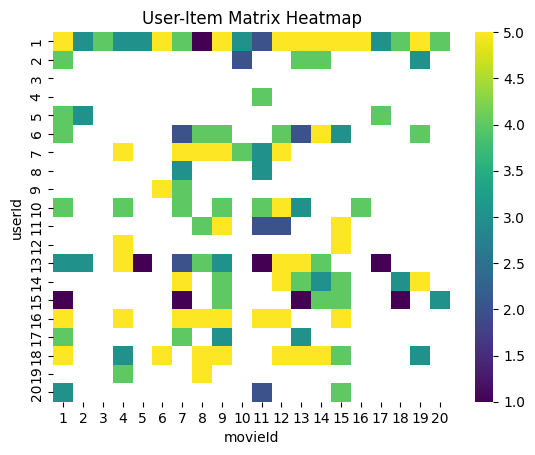

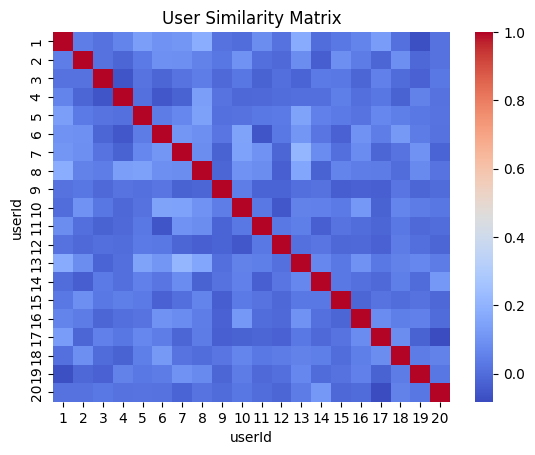

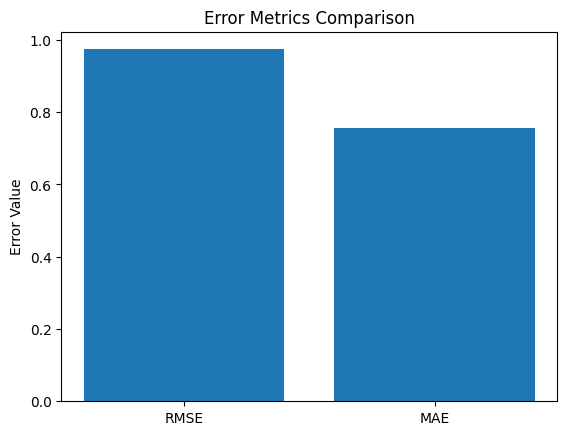

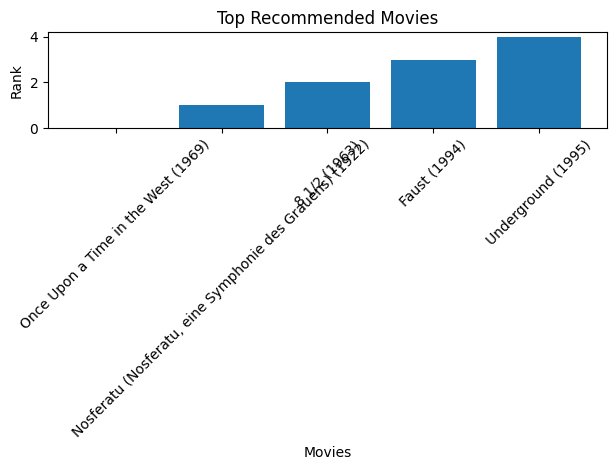

In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error


ratings = pd.read_csv(
    "/content/ml-100k/u.data",
    sep="\t",
    names=["userId", "movieId", "rating", "timestamp"]
)

movies = pd.read_csv(
    "/content/ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    names=["movieId", "title"] + [str(i) for i in range(22)]
)[["movieId", "title"]]


user_item = ratings.pivot(index='userId', columns='movieId', values='rating')


sparsity = 1.0 - (np.count_nonzero(user_item) / user_item.size)
print("\nSparsity:", round(sparsity * 100, 2), "%")


user_mean = user_item.mean(axis=1)
user_item_centered = user_item.sub(user_mean, axis=0)
user_item_filled = user_item_centered.fillna(0)


user_similarity = cosine_similarity(user_item_filled)
user_similarity_df = pd.DataFrame(user_similarity,
                                  index=user_item.index,
                                  columns=user_item.index)


def get_top_k_users(user_id, k=10):
    sim_scores = user_similarity_df[user_id].sort_values(ascending=False)
    sim_scores = sim_scores.drop(user_id)
    return sim_scores.head(k)


def predict_ratings(user_id, k=10):
    neighbors = get_top_k_users(user_id, k)
    mean_user = user_mean[user_id]
    pred = {}

    for movie in user_item.columns:
        numerator = 0
        denominator = 0

        for neighbor, sim in neighbors.items():
            if not np.isnan(user_item.loc[neighbor, movie]):
                numerator += sim * (user_item.loc[neighbor, movie] - user_mean[neighbor])
                denominator += abs(sim)

        if denominator != 0:
            pred[movie] = mean_user + (numerator / denominator)
        else:
            pred[movie] = mean_user

    return pd.Series(pred)


def recommend_movies(user_id, n=5):
    preds = predict_ratings(user_id)
    rated_movies = user_item.loc[user_id].dropna().index
    preds = preds.drop(rated_movies)
    top_movies = preds.sort_values(ascending=False).head(n)

    return movies[movies['movieId'].isin(top_movies.index)][['movieId', 'title']]


user_id = 1
print("\nTop Recommendations:\n")
print(recommend_movies(user_id, 5))


actual = []
predicted = []

for user in user_item.index[:50]:
    preds = predict_ratings(user)
    actual_ratings = user_item.loc[user].dropna()

    for movie in actual_ratings.index:
        actual.append(actual_ratings[movie])
        predicted.append(preds[movie])

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("\nImproved Evaluation:")
print("RMSE:", round(rmse, 3))
print("MAE:", round(mae, 3))


plt.figure()
sns.heatmap(user_item.iloc[:20, :20], cmap='viridis')
plt.title("User-Item Matrix Heatmap")
plt.show()

plt.figure()
sns.heatmap(user_similarity_df.iloc[:20, :20], cmap='coolwarm')
plt.title("User Similarity Matrix")
plt.show()

plt.figure()
metrics = ['RMSE', 'MAE']
values = [rmse, mae]
plt.bar(metrics, values)
plt.title("Error Metrics Comparison")
plt.ylabel("Error Value")
plt.show()

recommended = recommend_movies(user_id, 5)

plt.figure()
plt.bar(recommended['title'], range(len(recommended)))
plt.xticks(rotation=45)
plt.title("Top Recommended Movies")
plt.xlabel("Movies")
plt.ylabel("Rank")
plt.tight_layout()
plt.show()